In [17]:
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM
import matplotlib.pyplot as plt
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask
from functions import load_image

from functions import (load_image, get_prediction, predict_class, topk_predictions, generate_cam, generate_overlay, show_heatmap, show_overlay)

weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights = weights).eval()
preprocess = weights.transforms()

#img_pil = load_image("C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Rottweiler_Dog.jpg")

img_path = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Rottweiler_Dog.jpg"
class_index_path = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/imagenet_class_index.json"

#input_tensor = preprocess(img_pil)
#
#with LayerCAM(model) as cam_extractor:
#    out = model(input_tensor.unsqueeze(0))
#    activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

img_pil = load_image(img_path)

prediction = get_prediction(model, img_pil, preprocess)
pred_info = predict_class(prediction, class_index_path)

print(pred_info)


ImportError: cannot import name 'get_prediction' from 'functions' (c:\Users\samue\Documents\code\Machine-Learning-Samuel-Airisniemi\Labb2ny\functions.py)

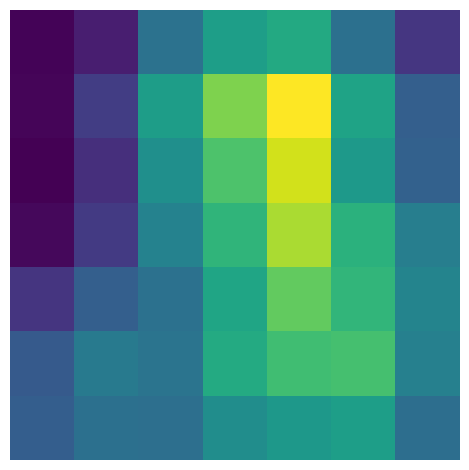

In [13]:
plt.imshow(activation_map[0].squeeze(0).numpy()); plt.axis("off"); plt.tight_layout(); plt.show()

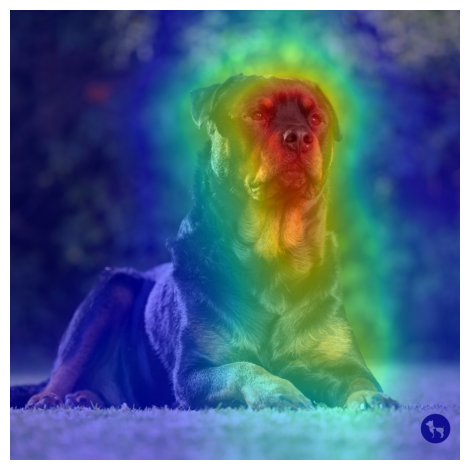

In [ ]:
result = overlay_mask(img_pil, to_pil_image(activation_map[0], mode = 'F'), alpha = 0.5)
plt.imshow(result); plt.axis('off'); plt.tight_layout(); plt.show()

In [15]:
model.eval()
preprocess = weights.transforms()
batch = preprocess(img_pil).unsqueeze(0)
prediction = model(batch).squeeze(0).softmax(0)
prediction.detach()

tensor([6.6143e-07, 1.2208e-07, 4.8236e-09, 1.0272e-08, 1.7638e-08, 2.2446e-07,
        2.5294e-08, 8.4956e-07, 3.0140e-07, 1.4429e-07, 1.6014e-06, 3.5972e-08,
        2.3810e-08, 7.2768e-08, 3.6781e-07, 3.6103e-06, 7.0108e-10, 2.4297e-08,
        4.8345e-08, 9.1607e-09, 8.9928e-08, 2.0610e-06, 5.2217e-07, 6.3594e-07,
        3.4953e-06, 3.4853e-06, 3.7462e-06, 2.4814e-06, 2.4345e-06, 2.7795e-08,
        1.1656e-07, 5.1151e-08, 2.0741e-07, 2.7009e-06, 1.3033e-06, 2.0157e-05,
        3.7892e-06, 3.3350e-06, 1.5184e-07, 7.5603e-07, 2.1964e-08, 1.1118e-07,
        3.2754e-07, 3.6147e-07, 2.0658e-07, 4.2941e-07, 7.9577e-08, 1.9268e-07,
        1.9387e-07, 3.6835e-07, 6.6040e-07, 5.4617e-07, 3.8685e-07, 3.2184e-07,
        2.8739e-07, 9.0836e-08, 8.0102e-08, 7.8271e-07, 6.7992e-07, 7.8697e-08,
        3.6450e-07, 6.0281e-07, 3.4828e-07, 2.0720e-06, 3.9459e-07, 4.9915e-07,
        1.7274e-07, 2.6614e-07, 2.2237e-07, 3.4664e-08, 3.1962e-08, 1.6397e-07,
        2.4578e-07, 1.1337e-07, 6.1060e-

In [16]:
import json
import torch

def predict_class(output_tensor: torch.Tensor, class_index_path: str) -> dict:
    with open(class_index_path, "r") as f:
        class_index = json.load(f)
    probs = output_tensor.squeeze()
    if probs.ndim != 1 or probs.shape[0] != 1000:
        raise ValueError(f"Expected a tensor of 1000 values, got shape {tuple(output_tensor.shape)}")
    top_idx = int(probs.argmax())
    synset_id, class_name = class_index[str(top_idx)]

    return {
        "class_index": top_idx,
        "class_id":    synset_id,
        "class_name":  class_name,
        "confidence":  float(probs[top_idx]),
    }

predict_class(prediction.detach(), "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/imagenet_class_index.json")

{'class_index': 234,
 'class_id': 'n02106550',
 'class_name': 'Rottweiler',
 'confidence': 0.9185128808021545}